# Final TraceWin policy benchmark

This report focuses on one configuration only:
`thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo`, evaluated on real TraceWin workspace 3
over 20 matched-reset episodes with a maximum of 30 steps. The policies were trained
with a 20-step horizon; 30 steps are used only for this final TraceWin evaluation.

It contains only the artifacts needed for the final decision:

- dataset-042 policy training;
- the exact bar and box plots from this 30-step benchmark;
- reliability-based selection of the best policy;
- comparison with warm-started Bayesian Optimization;
- operational timing at the end.

No training or TraceWin simulation is launched here. The notebook reads the saved
artifacts and renders a concise, reproducible summary.

In [1]:
from datetime import datetime
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "beam_optimization" / "config" / "adige.py").is_file():
            return candidate
    raise FileNotFoundError("Repository root not found")


REPO_ROOT = find_repository_root()
RESULTS_DIR = REPO_ROOT / "beam_optimization" / "results"
TRAIN_DIR = RESULTS_DIR / "train" / "rl" / "thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo"
BENCHMARK_DIR = RESULTS_DIR / "benchmark"
BENCHMARK_30_DIR = (BENCHMARK_DIR
                    / "thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo_workspace3_30steps")
BENCHMARK_30_PATH = (BENCHMARK_30_DIR
                     / "thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo_workspace3_30steps_tracewin.json")
BENCHMARK_EPISODES_PATH = BENCHMARK_30_DIR / "benchmark_policy_episodes_tracewin.csv"
BAYESIAN_DIR = RESULTS_DIR / "bayesian_opt" / "warm_start_workspace1_5x300"
for required in (TRAIN_DIR, BENCHMARK_30_PATH, BENCHMARK_EPISODES_PATH,
                 BAYESIAN_DIR / "results.json"):
    assert required.exists(), f"Missing required artifact: {required}"

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#d9d9d9",
    "grid.alpha": 0.45,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "legend.frameon": False,
})

print("Training run :", TRAIN_DIR)
print("30-step data:", BENCHMARK_30_PATH)
print("Episode CSV :", BENCHMARK_EPISODES_PATH)
print("Bayesian data:", BAYESIAN_DIR)

Training run : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/train/rl/thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo
30-step data: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo_workspace3_30steps/thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo_workspace3_30steps_tracewin.json
Episode CSV : /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/benchmark/thesis_042_0_softplus_clean_a015_s025_h20_steps300k_definitivo_workspace3_30steps/benchmark_policy_episodes_tracewin.csv
Bayesian data: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/results/bayesian_opt/warm_start_workspace1_5x300


## 1. Dataset-042 training

All policies were optimized using the dataset-042 surrogate setup. Model-free agents use a budget
of 300,000 environment steps over three seeds (42, 43 and 44). SVG differentiates through the
surrogate dynamics and therefore does not interact with the environment through the classic
step-by-step RL loop. The curves below are surrogate evaluations during training; final selection
is based on the real-TraceWin benchmark in section 2. Training episodes use a maximum of 20 steps.

,promoted seed,training best mean,training best std
algorithm,,,
td3,43,68.59,0.54
svg_final,43,69.06,0.07
sac,42,66.32,1.08
svg_uniform,43,73.79,0.01
ppo,44,69.05,0.52
ddpg,44,63.43,0.27
a2c,44,62.61,0.51


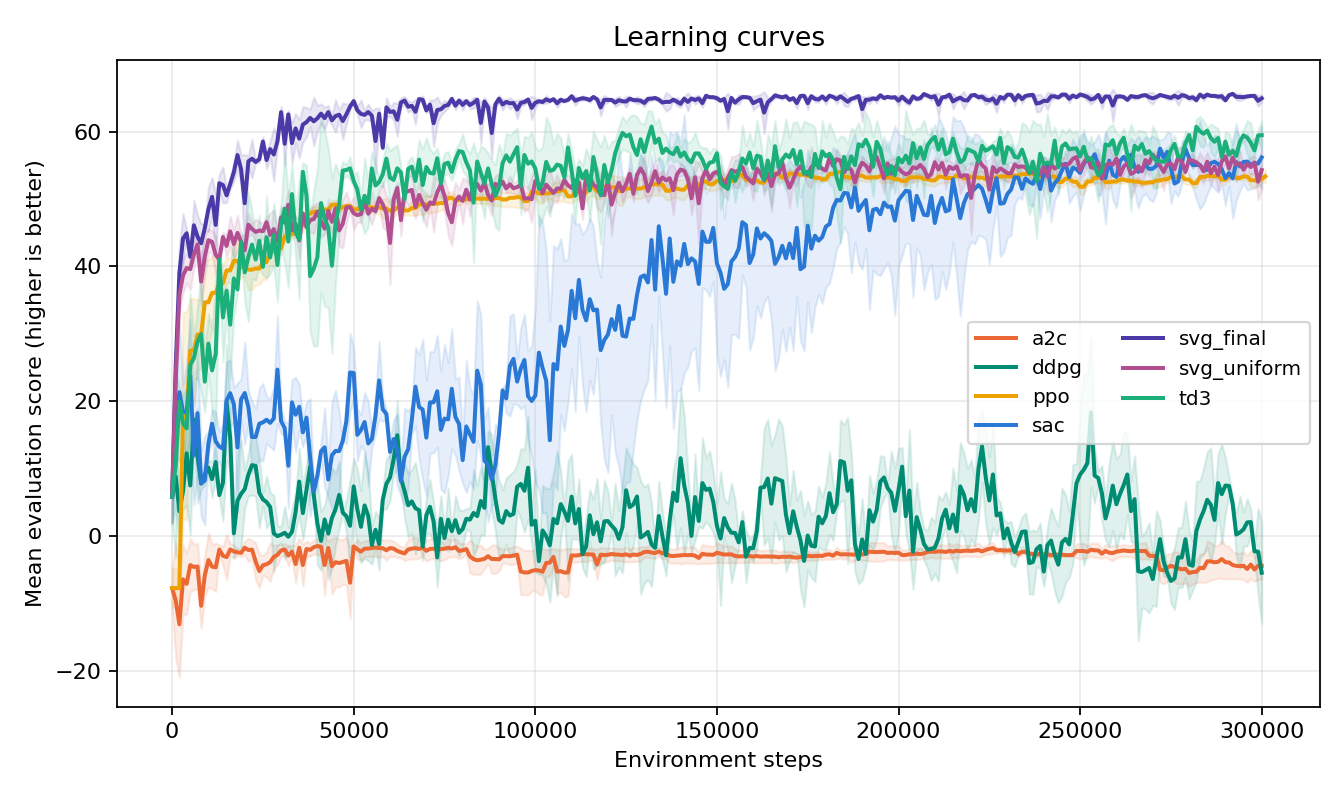

In [2]:
training_summary = json.loads((TRAIN_DIR / "summary.json").read_text())
algorithms = ["td3", "svg_final", "sac", "svg_uniform", "ppo", "ddpg", "a2c"]

training_rows = []
for algorithm in algorithms:
    row = training_summary[algorithm]
    training_rows.append({
        "algorithm": algorithm,
        "promoted seed": int(row["best_seed"]),
        "training best mean": float(row["best_score_mean"]),
        "training best std": float(row["best_score_std"]),
    })
training_df = pd.DataFrame(training_rows).set_index("algorithm")
display(training_df.style.format({
    "training best mean": "{:.2f}", "training best std": "{:.2f}",
}))
display(Image(filename=str(TRAIN_DIR / "learning_curves.png")))

## 2. Final evaluation on real TraceWin: 30-step episodes

Each promoted policy is evaluated over 20 matched reset seeds on workspace 3. Every episode can run
for at most 30 steps and terminates earlier if the beam is lost. A failure is a final score equal to
`ERROR_SCORE = -999`. The ranking uses the final state left by the policy, not the best state visited
temporarily during its trajectory.

,episodes,score mean,score std,score median,mean npart ratio,failures,failure rate,best observed score,best observed step
svg_final,20,71.79,5.44,73.51,0.705,0,0%,76.77,30
sac,20,62.51,12.24,66.15,0.630,0,0%,72.20,18
td3,20,16.85,233.07,70.78,0.671,1,5%,74.79,26
svg_uniform,20,6.14,230.69,59.36,0.557,1,5%,68.35,9
a2c,20,-2.83,4.75,-3.32,0.082,0,0%,38.69,3
ppo,20,-7.25,227.75,43.12,0.441,1,5%,73.71,30
ddpg,20,-152.84,355.54,-3.88,0.162,3,15%,54.88,3


**Bar plot for this exact run** — `benchmark_policy_bars_tracewin.png`

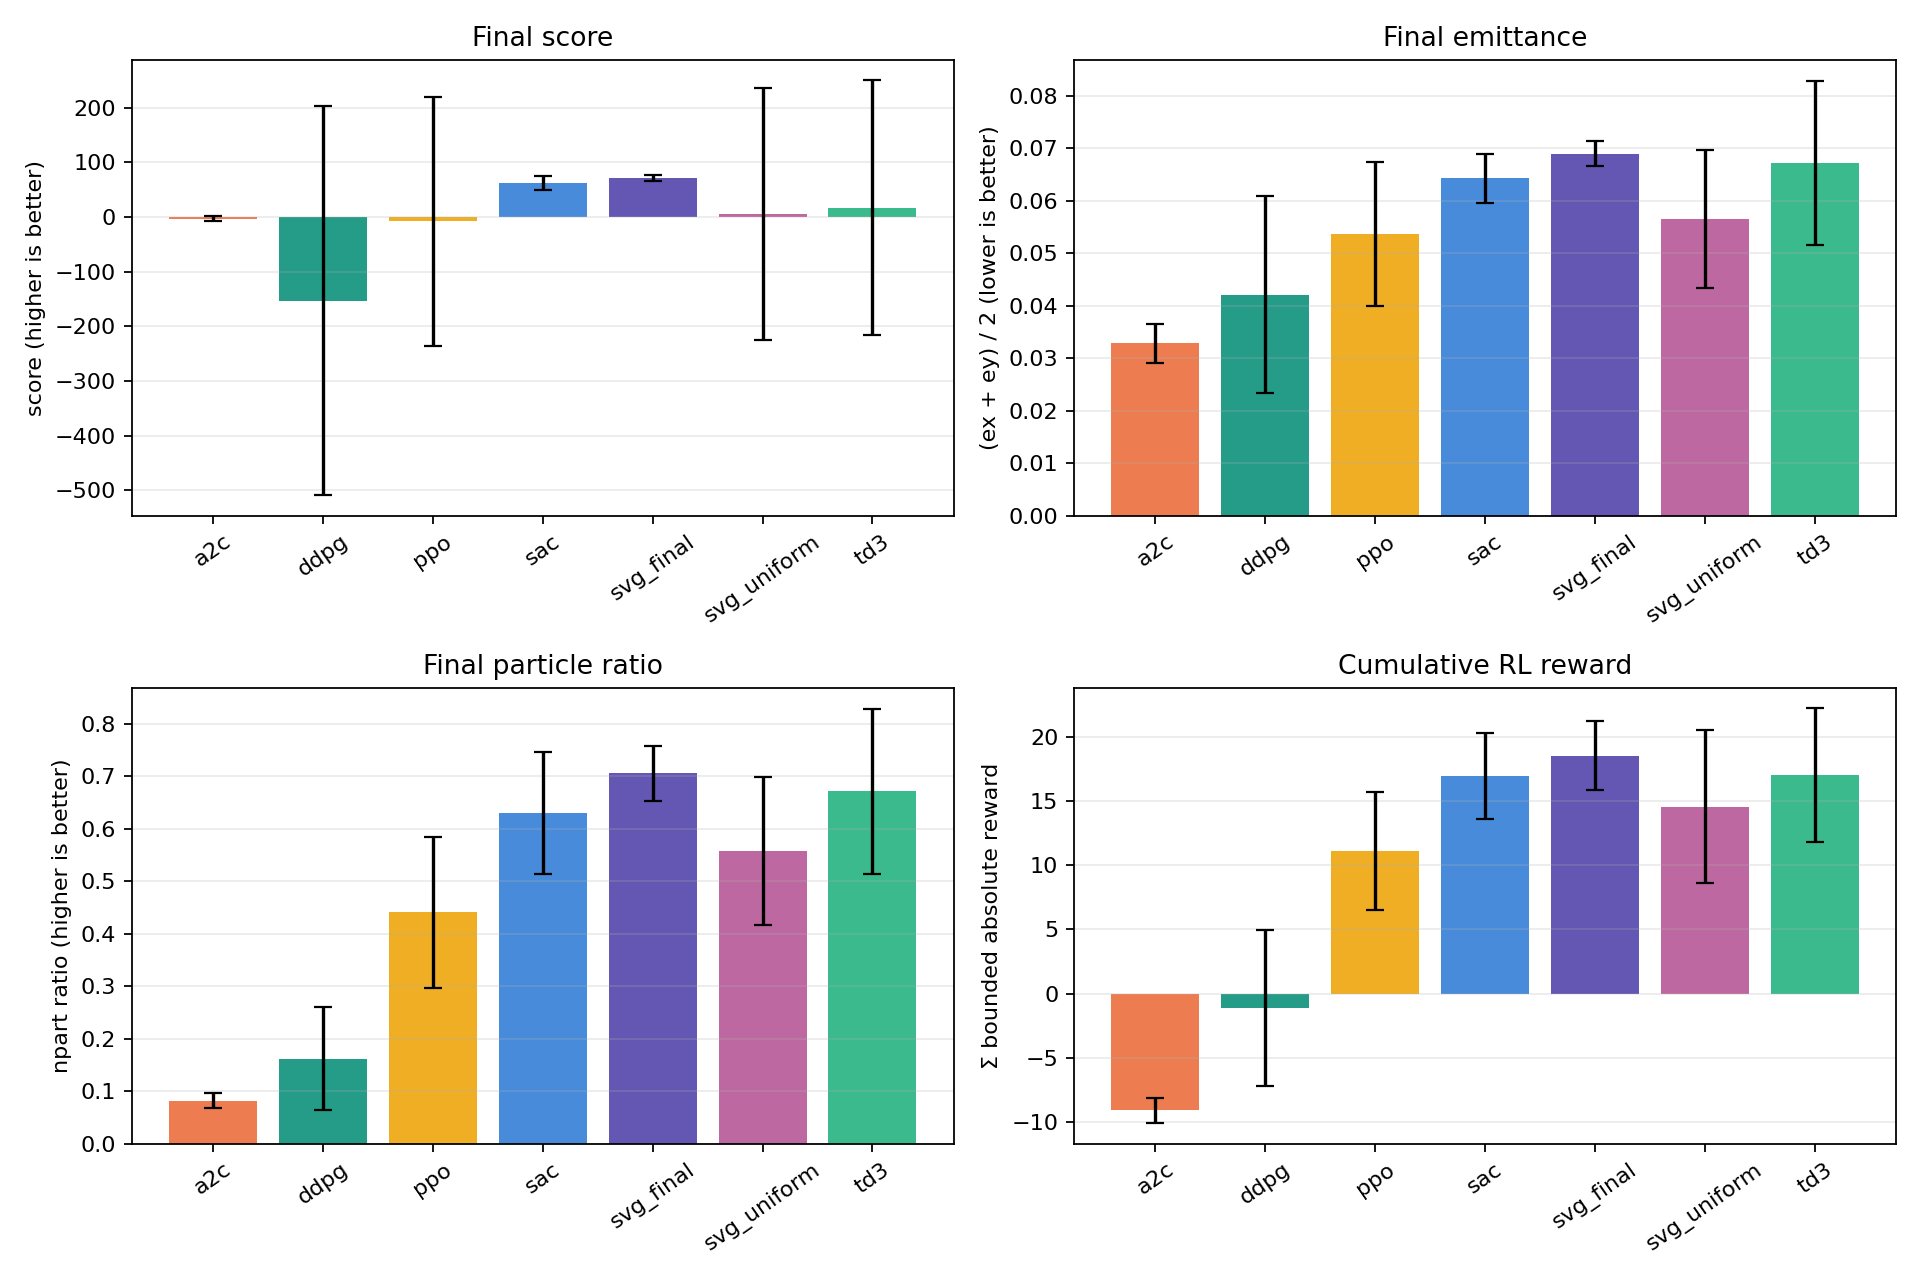

**Box plot for this exact run** — `benchmark_policy_boxplots_tracewin.png`

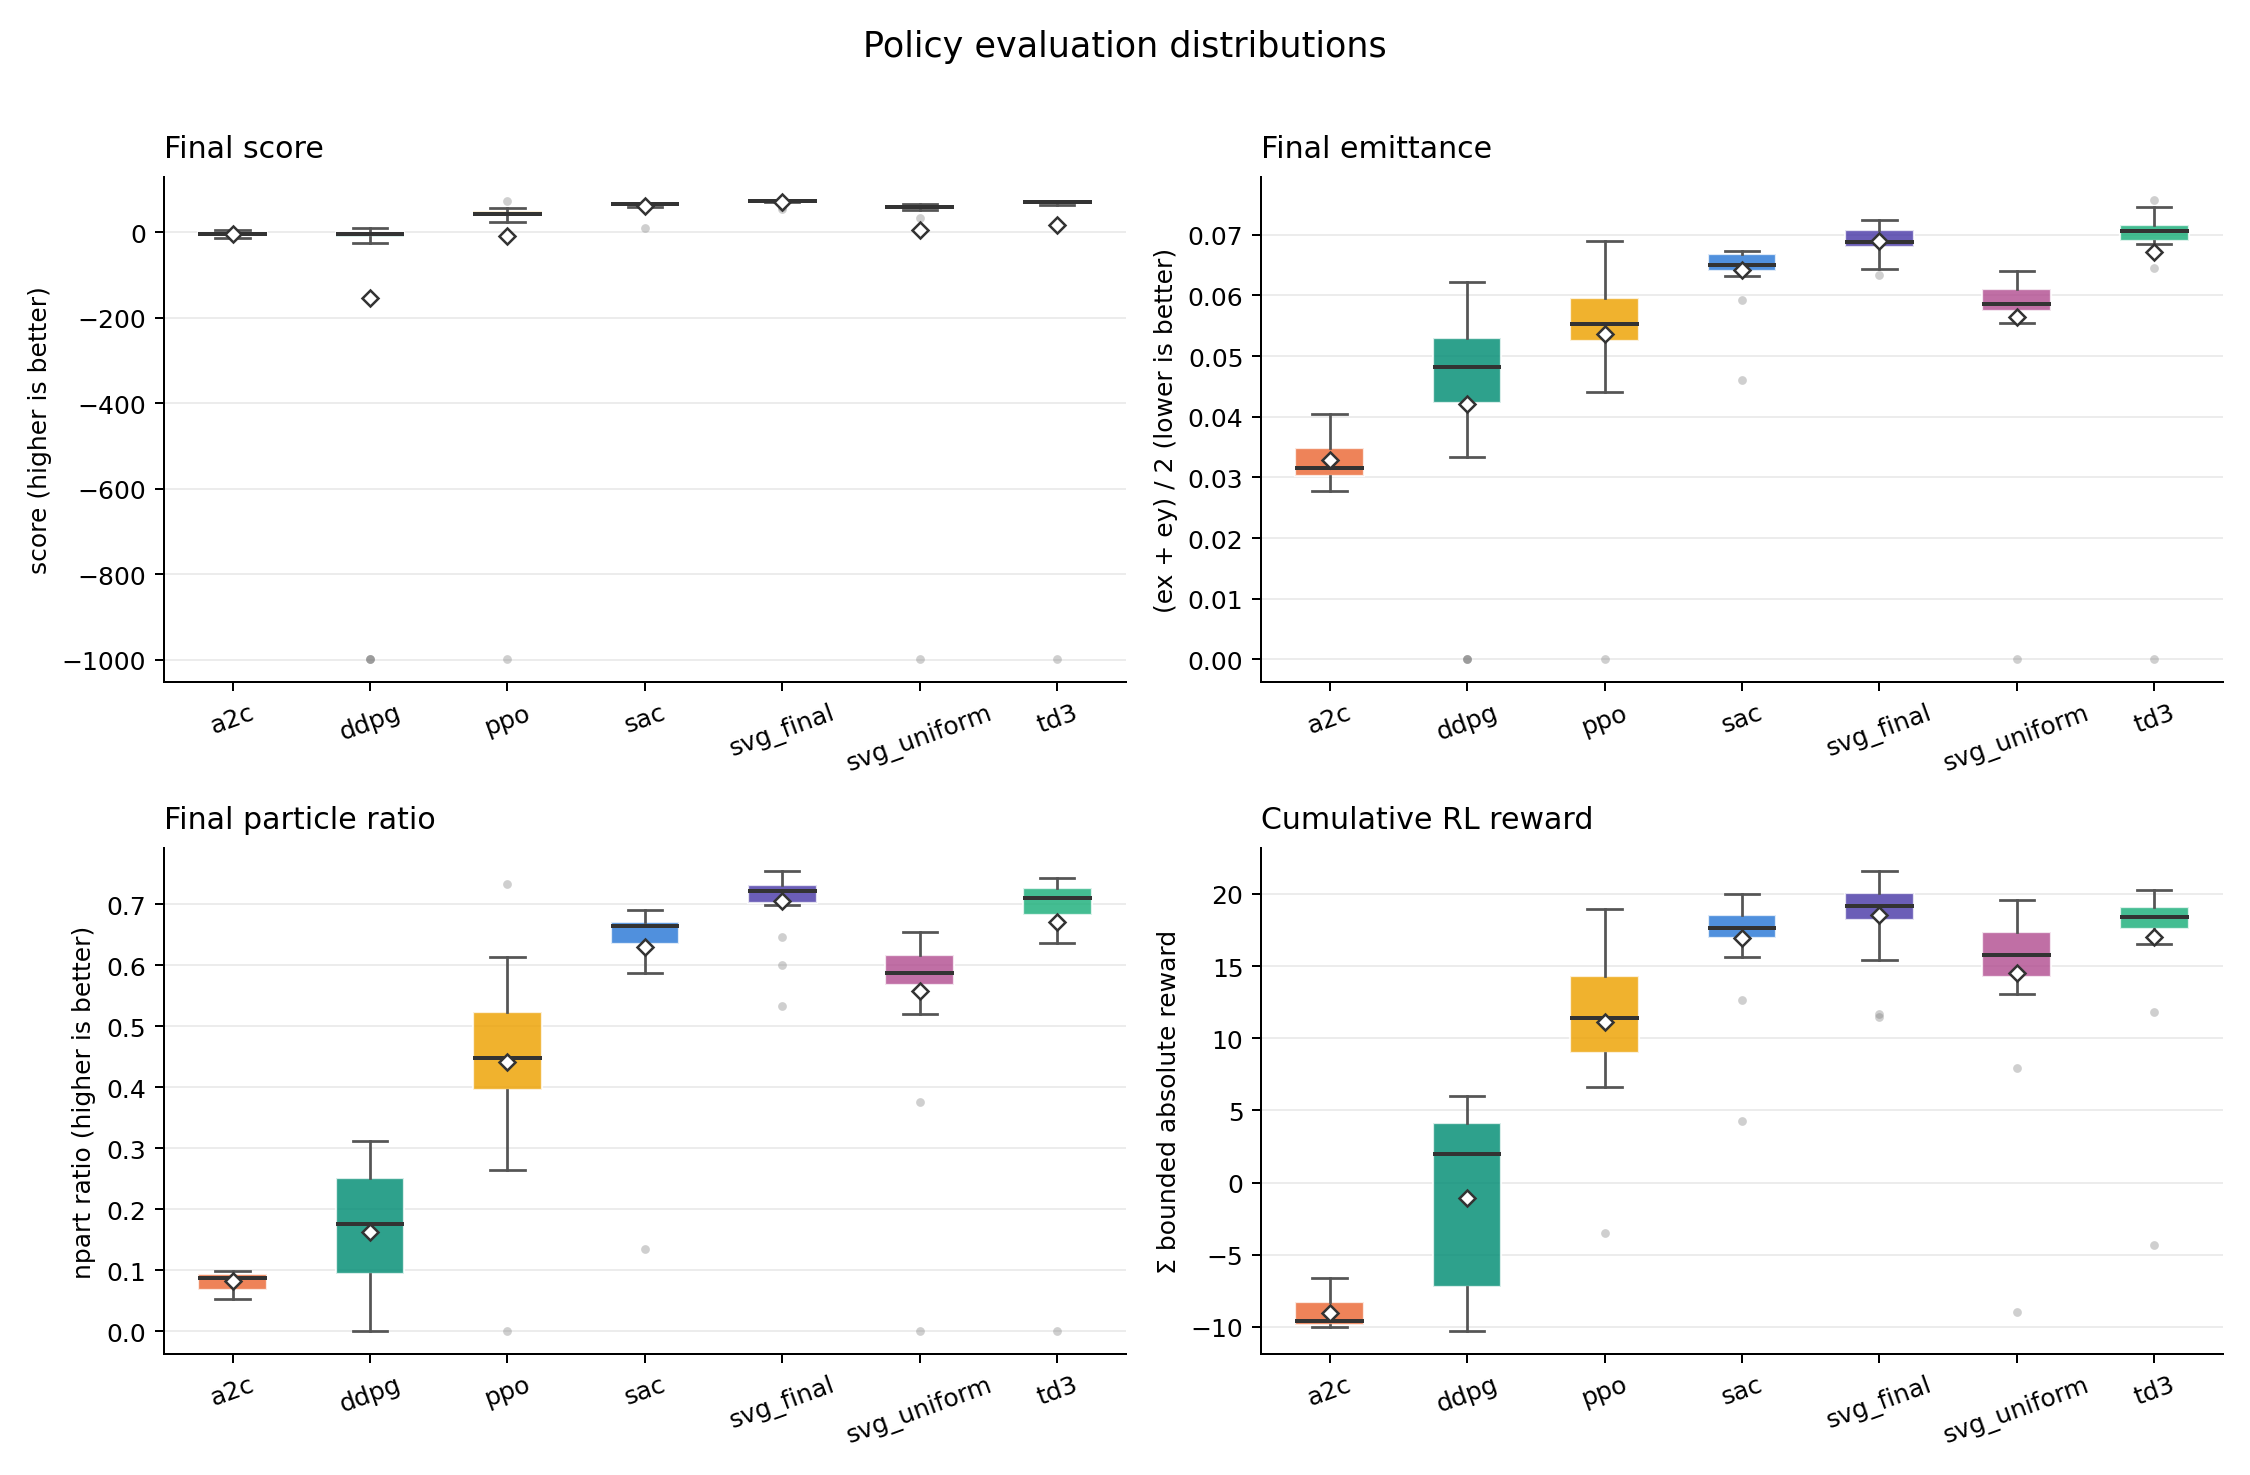

In [3]:
benchmark_30 = json.loads(BENCHMARK_30_PATH.read_text())
tracewin_30 = benchmark_30["policy_evaluation_tracewin"]
episodes_30 = pd.read_csv(BENCHMARK_EPISODES_PATH)
error_score = float(benchmark_30["score_function"]["error_score"])


def compact_summary(tracewin, episodes, error_score):
    raw = pd.DataFrame(tracewin["summary"]).T.copy()
    failures = episodes.groupby("algorithm")["final_score"].apply(
        lambda values: int(np.isclose(values, error_score).sum())
    )
    medians = episodes.groupby("algorithm")["final_score"].median()
    result = pd.DataFrame({
        "episodes": raw["episodes"].astype(int),
        "score mean": raw["final_score_mean"],
        "score std": raw["final_score_std"],
        "score median": medians,
        "mean npart ratio": raw["final_npart_ratio_mean"],
        "failures": failures,
        "failure rate": failures / raw["episodes"],
        "best observed score": raw["best_observed_score"],
        "best observed step": raw["best_observed_step"].astype(int),
    })
    return result.sort_values("score mean", ascending=False)


summary_30 = compact_summary(tracewin_30, episodes_30, error_score)
display(summary_30.style.format({
    "score mean": "{:.2f}", "score std": "{:.2f}", "score median": "{:.2f}",
    "mean npart ratio": "{:.3f}", "failure rate": "{:.0%}",
    "best observed score": "{:.2f}", "best observed step": "{:d}",
}).background_gradient(subset=["score mean"], cmap="RdYlGn"))

bar_plot_30 = BENCHMARK_30_DIR / "benchmark_policy_bars_tracewin.png"
box_plot_30 = BENCHMARK_30_DIR / "benchmark_policy_boxplots_tracewin.png"
display(Markdown(f"**Bar plot for this exact run** — `{bar_plot_30.name}`"))
display(Image(filename=str(bar_plot_30)))
display(Markdown(f"**Box plot for this exact run** — `{box_plot_30.name}`"))
display(Image(filename=str(box_plot_30)))

`svg_final` is the strongest policy in this benchmark: it completes all 20 episodes without losing
the beam and ranks first by final-score mean (**71.79 ± 5.44**). Its best observed score,
**76.77**, is reached at **step 30** of episode index 17. `sac` and `a2c`
also have zero failures but lower mean scores. The `best observed step` column reports where
each policy reaches its trajectory-wise maximum across all matched-reset episodes.
Terminal failures substantially reduce the averages of `td3`, `svg_uniform`, `ppo` and `ddpg`.

## 3. Bayesian Optimization reference

The reference campaign contains five independent warm-started runs with 300 new real-TraceWin
evaluations each. Its best score is a selected static optimum, not a mean across reset episodes, so
it is not inserted into the policy ranking. The plots show convergence and the best configuration's
shift from the nominal machine settings.

,value
independent runs,5
new evaluations per run,300
total new evaluations,1500
successful evaluations,1492
failed evaluations,8
warm-start points reused,46
best score,60.35879
best run,5
best call in run,183


**Convergence by new TraceWin evaluations**

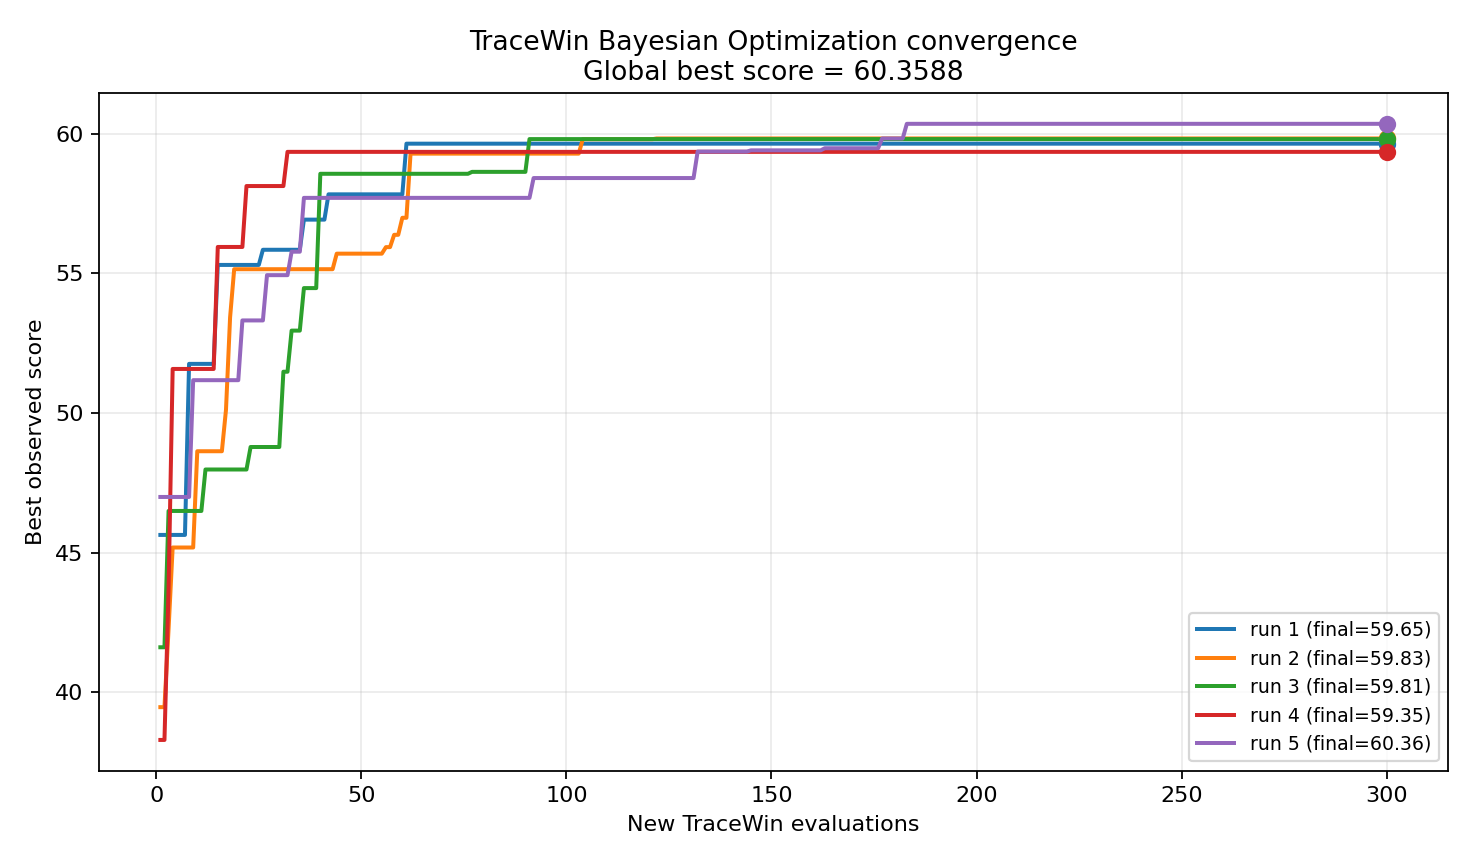

**Best-configuration shift from the nominal default**

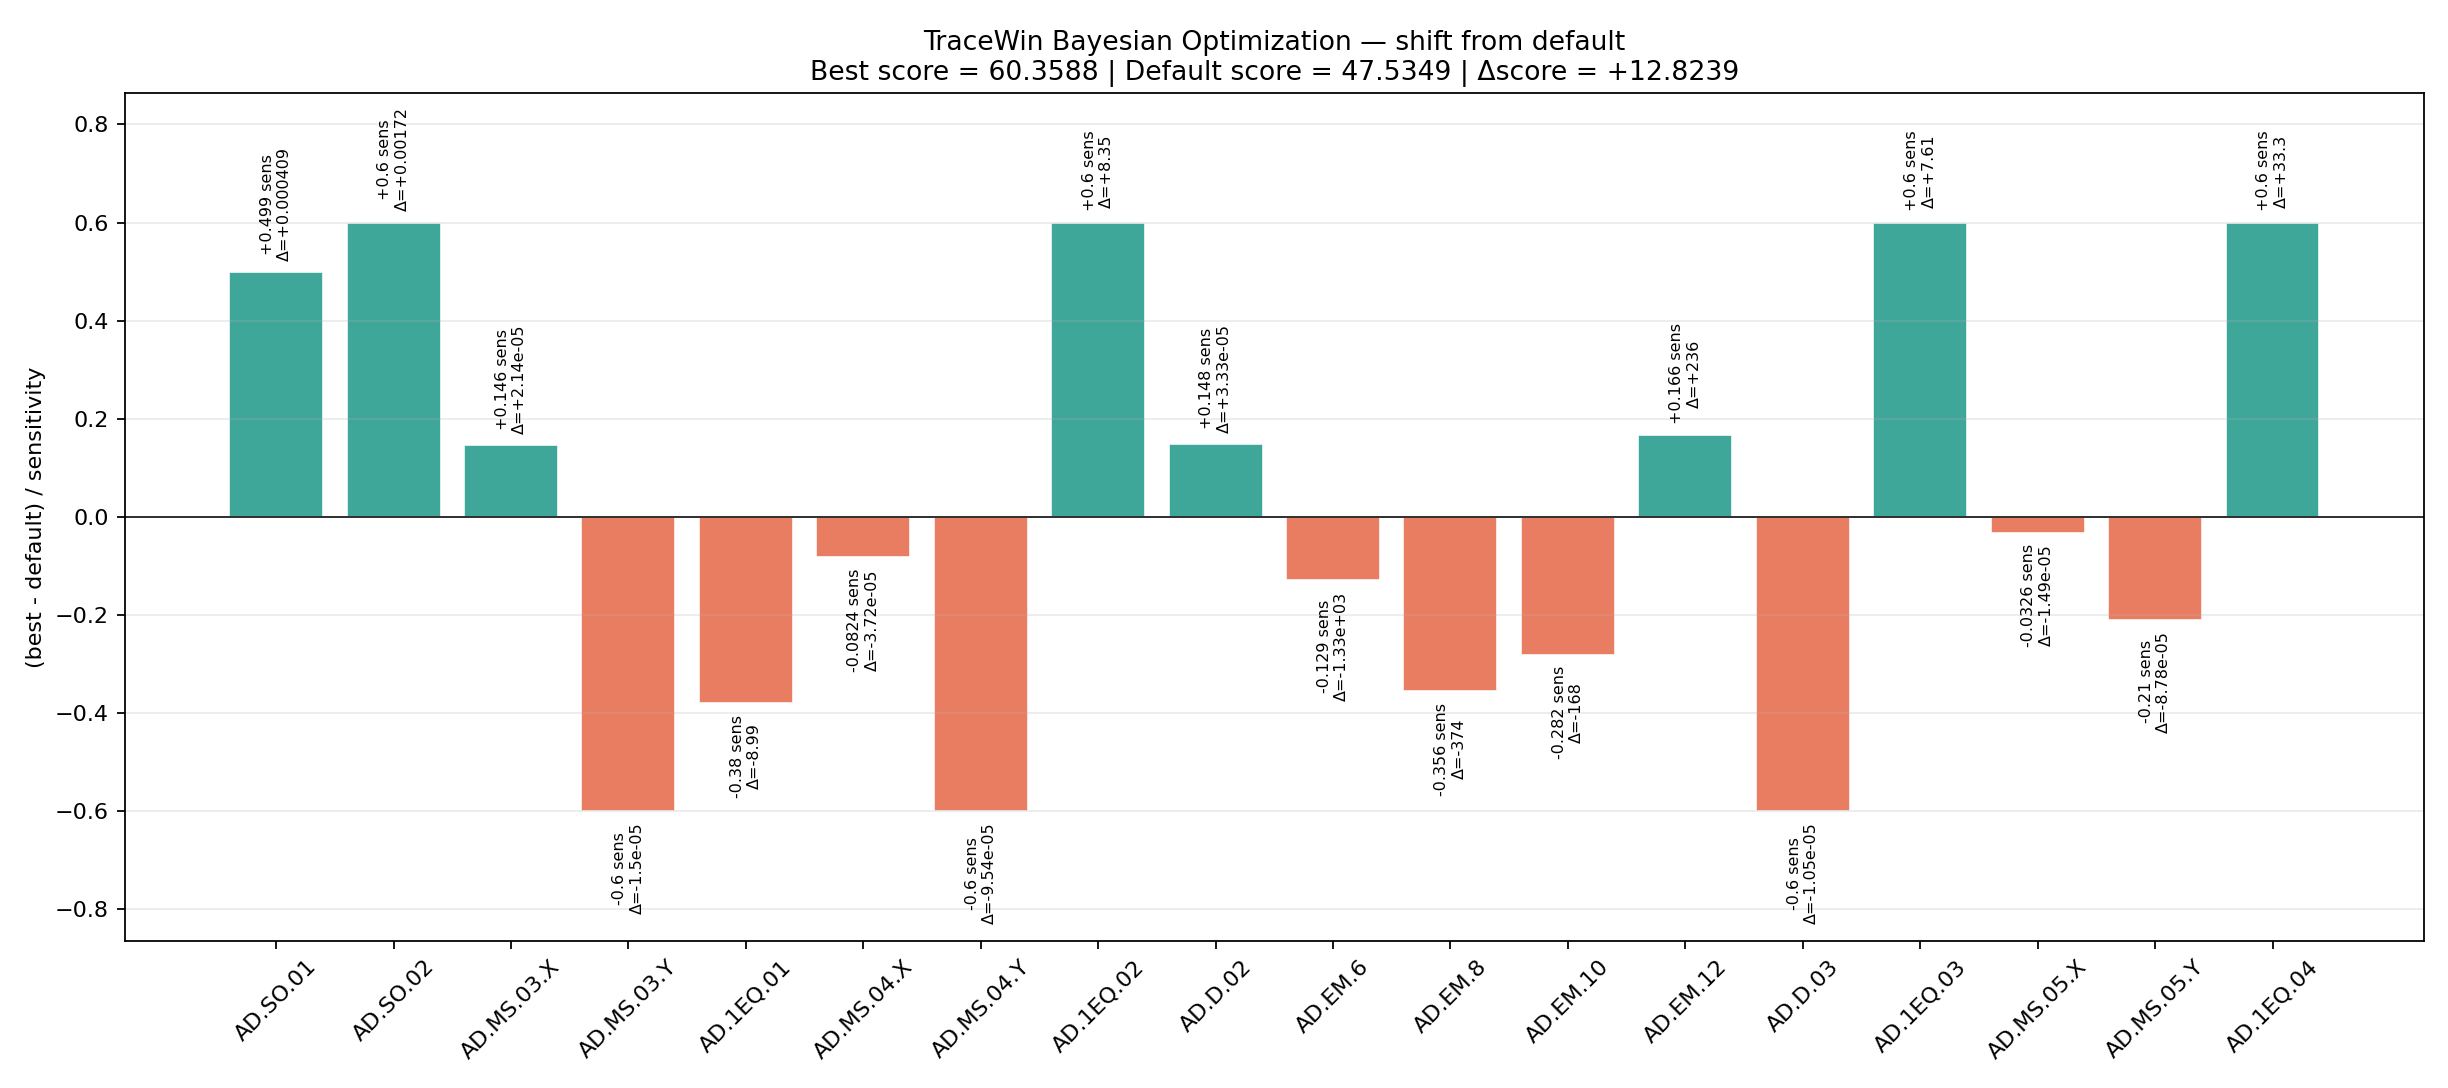

In [4]:
bayesian_report = json.loads((BAYESIAN_DIR / "results.json").read_text())
assert bayesian_report["score_function"]["sha256"] == benchmark_30["score_function"]["sha256"]
bayesian_best = bayesian_report["best_result"]
bayesian_evaluations = [row for run in bayesian_report["runs"] for row in run["evaluations"]]

bayesian_summary = pd.DataFrame({"value": {
    "independent runs": len(bayesian_report["runs"]),
    "new evaluations per run": bayesian_report["config"]["n_calls"],
    "total new evaluations": len(bayesian_evaluations),
    "successful evaluations": sum(bool(row.get("success")) for row in bayesian_evaluations),
    "failed evaluations": sum(not bool(row.get("success")) for row in bayesian_evaluations),
    "warm-start points reused": len(bayesian_report.get("warm_start", [])),
    "best score": f"{bayesian_best['score']:.5f}",
    "best run": int(bayesian_best["run_index"]) + 1,
    "best call in run": int(bayesian_best["call_index"]) + 1,
}})
display(bayesian_summary)

display(Markdown("**Convergence by new TraceWin evaluations**"))
display(Image(filename=str(BAYESIAN_DIR / "bayesian_opt_convergence.png")))
display(Markdown("**Best-configuration shift from the nominal default**"))
display(Image(filename=str(BAYESIAN_DIR / "bayesian_opt_delta.png")))

## 4. Final decision

- **SVG final is the policy to test:** 71.79 ± 5.44 final score, zero failures and best observed score 76.77.
- Bayesian Optimization reaches 60.36 as a selected static optimum, but this remains a
  different statistic from a policy's mean across resets.
- `td3`, `svg_uniform`, `ppo` and `ddpg` record at least one terminal beam loss; `a2c` is reliable but has a much lower score.

## 5. Timing: one Bayesian run vs one SVG-final test episode

This final comparison considers the intended operations after policy selection:

- one complete Bayesian run: 300 TraceWin evaluations;
- one SVG-final test episode: 30 environment steps, hence 30 TraceWin calls.

Bayesian durations are measured from saved timestamps. The policy-episode duration is estimated as
`30 × measured mean TraceWin-call time`, because the policy benchmark does not record timestamps.

**Measured Bayesian duration by run**

,TraceWin calls,duration min,average s/call,best score
run,,,,
1,300,134.7,27.0,59.65
2,300,124.3,24.9,59.83
3,300,119.0,23.9,59.81
4,300,112.8,22.6,59.35
5,300,117.2,23.5,60.36


**Direct operational comparison**

,TraceWin calls,duration min,basis
operation,,,
SVG final: one 30-step test episode,30,12.2,estimated: 30 × mean call time
Bayesian Optimization: one complete run,300,121.6,measured mean across 5 runs


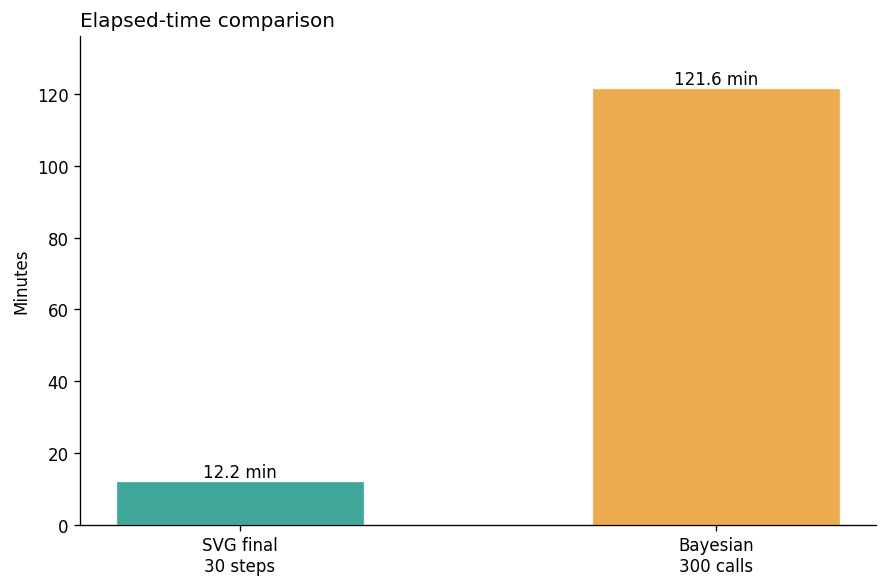

In [5]:
def parse_timestamp(value):
    return datetime.fromisoformat(value)


timing_rows = []
for run in bayesian_report["runs"]:
    timed = [row for row in run["evaluations"] if row.get("timestamp")]
    timestamps = [parse_timestamp(row["timestamp"]) for row in timed]
    duration_seconds = (max(timestamps) - min(timestamps)).total_seconds()
    timing_rows.append({
        "run": int(run["run_index"]) + 1,
        "TraceWin calls": len(timed),
        "duration min": duration_seconds / 60,
        "average s/call": duration_seconds / max(1, len(timed) - 1),
        "best score": run["best_score"],
    })

bayesian_timing = pd.DataFrame(timing_rows).set_index("run")
mean_call_seconds = (bayesian_timing["duration min"].sum() * 60
                     / (bayesian_timing["TraceWin calls"].sum() - len(bayesian_timing)))
mean_bayesian_run_minutes = bayesian_timing["duration min"].mean()
policy_episode_minutes = 30 * mean_call_seconds / 60

display(Markdown("**Measured Bayesian duration by run**"))
display(bayesian_timing.style.format({
    "duration min": "{:.1f}", "average s/call": "{:.1f}", "best score": "{:.2f}",
}))

timing_comparison = pd.DataFrame([
    {"operation": "SVG final: one 30-step test episode", "TraceWin calls": 30,
     "duration min": policy_episode_minutes, "basis": "estimated: 30 × mean call time"},
    {"operation": "Bayesian Optimization: one complete run", "TraceWin calls": 300,
     "duration min": mean_bayesian_run_minutes, "basis": "measured mean across 5 runs"},
]).set_index("operation")
display(Markdown("**Direct operational comparison**"))
display(timing_comparison.style.format({"duration min": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(7.5, 5.0))
labels = ["SVG final\n30 steps", "Bayesian\n300 calls"]
values = [policy_episode_minutes, mean_bayesian_run_minutes]
ax.bar(
    labels,
    values,
    color=["#2A9D8F", "#E9A23B"],
    alpha=0.9,
    width=0.52,
    edgecolor="white",
    linewidth=0.8,
)
for index, value in enumerate(values):
    ax.text(index, value, f"{value:.1f} min", ha="center", va="bottom")
ax.set_title("Elapsed-time comparison", loc="left")
ax.set_ylabel("Minutes")
ax.set_ylim(0, max(values) * 1.12)
ax.grid(axis="y")
ax.grid(False, axis="x")
fig.tight_layout()
plt.show()

A TraceWin call takes **24.4 seconds on average** in the recorded Bayesian campaign. Therefore,
one SVG-final episode is approximately **12.2 minutes**, while one complete Bayesian run takes **121.6
minutes on average**. The Bayesian run costs about **10 times more calls and wall-clock time** than
one deployment episode of the already selected policy. Policy training is excluded because it was
performed offline on the surrogate.